In [1]:
import glob, pickle
import numpy as np
import matplotlib.pyplot as plt

PKL_DIR = "../data/cms/phase2/offline/Aug31/nano/pkl_output"
files = sorted(glob.glob(f"{PKL_DIR}/*.pkl"))
samples = sorted({f.split("/")[-1].rsplit("_", 2)[0] for f in files})
print(f"{len(files)} files, {sum(1 for _ in files)} total; samples: {samples}")

with open(files[0], "rb") as fh:
    evts = pickle.load(fh)          # a list of per-event dicts
print(f"\n{files[0].split('/')[-1]}: {len(evts)} events")
ev = evts[0]
for k, v in ev.items():
    print(f"  {k:<17} {type(v).__name__:<10} {getattr(v, 'shape', '')}")

print("\nXelem fields  :", list(ev["Xelem"].dtype.names))
print("ytarget fields:", list(ev["ytarget"].dtype.names))

X = np.concatenate([e["Xelem"] for e in evts])
Y = np.concatenate([e["ytarget"] for e in evts])
C = np.concatenate([e["ycand"] for e in evts])
ne = np.array([len(e["Xelem"]) for e in evts])
print(f"\nelements/event: mean {ne.mean():.1f}  min {ne.min()}  max {ne.max()}   ({len(X)} total)")

TYP = {1: "track", 2: "EM trackster", 3: "HAD trackster", 4: "GSF track"}
for tv, lab in TYP.items():
    m = X["typ"] == tv
    if m.sum():
        pid, cnt = np.unique(Y["pid"][m].astype(int), return_counts=True)
        print(f"  typ {tv} {lab:<14} {m.sum():6d} ({100*m.mean():4.1f}%)   target pids {dict(zip(pid.tolist(), cnt.tolist()))}")

for name, arr in [("ytarget", Y), ("ycand", C)]:
    pid, cnt = np.unique(arr["pid"].astype(int), return_counts=True)
    print(f"\n{name} pid: " + "  ".join(f"{p}:{100*c/cnt.sum():.2f}%" for p, c in zip(pid, cnt)))
    print(f"   energy sum {arr['energy'].sum():.0f} GeV")


7486 files, 7486 total; samples: ['ticl_qcd_nopu', 'ticl_ttbar_nopu', 'ticl_zll_nopu']

ticl_qcd_nopu_0_0000.pkl: 1200 events
  Xelem             recarray   (29,)
  ycand             recarray   (29,)
  ytarget           recarray   (29,)
  genjet            ndarray    (1, 4)
  targetjet         ndarray    (1, 4)
  genmet            ndarray    (2,)
  pythia            ndarray    (5, 5)
  event_idx         int        
  file_name         str        
  global_event_idx  int        

Xelem fields  : ['typ', 'pt', 'eta', 'phi', 'energy', 'charge', 'px', 'py', 'pz', 'em_energy', 'bary_z', 'nhits', 'min_dR_track', 'near_track_pt', 'shower_depth', 'sum_pt_dR10', 'n_trk_dR01', 'n_trk_dR02', 'n_trk_dR03', 'n_trk_dR04', 'n_trk_dR05', 'n_clusters', 'ts_time', 'ts_time_err', 'track_muon_type', 'track_muon_dt_hits', 'track_muon_csc_hits', 'track_gsf_type', 'track_pt_err', 'track_eta_err', 'track_phi_err', 'track_lambda_err', 'track_qoverp_err', 'track_vx', 'track_vy', 'track_vz']
ytarget fields: ['pi

/var/folders/z8/kkxz8ypj3jd1m6y16bw_d1vw0000gn/T/ipykernel_47479/3590457085.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  evts = pickle.load(fh)          # a list of per-event dicts


#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  


/var/folders/z8/kkxz8ypj3jd1m6y16bw_d1vw0000gn/T/ipykernel_47479/2852366608.py:41: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  for ev in pickle.load(open(fn, "rb")):


# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
ticl_ttbar_nopu, 12 files
  gen jets (pt>5.0, no neutrinos): 25775
  target  matched  21014 ( 81.5%)   median 0.9021   IQR 0.2515
  cand    matched  19304 ( 74.9%)   median 0.8235   IQR 0.4979


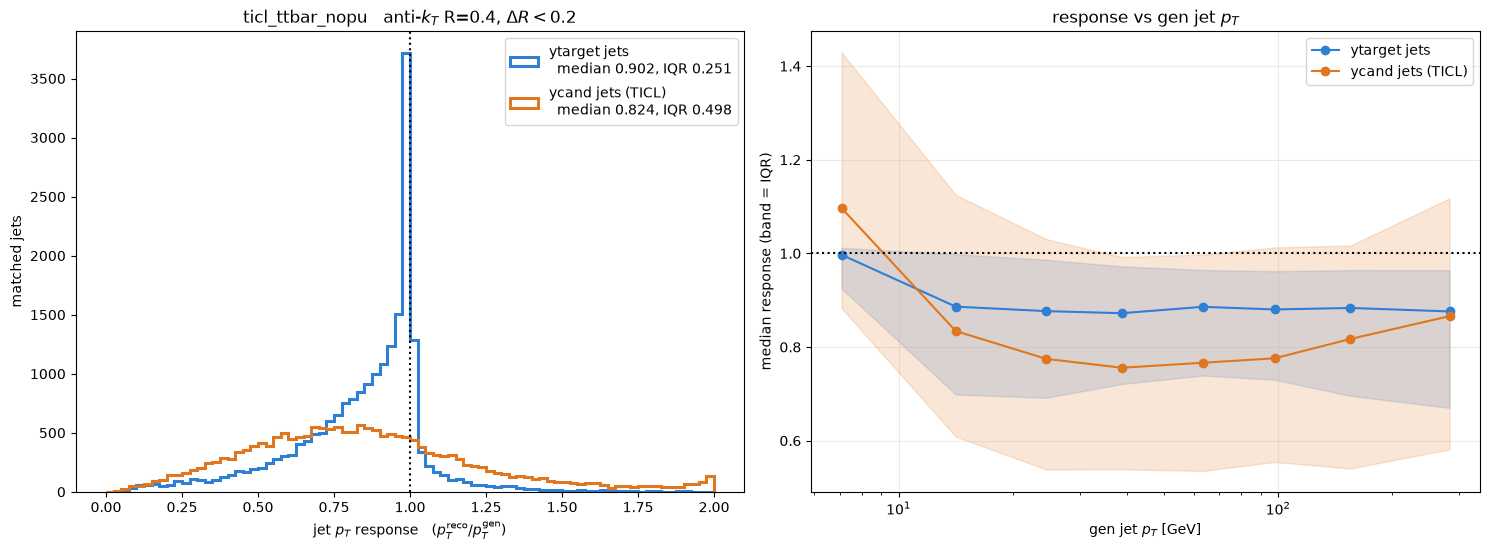

In [2]:
import glob, pickle
import numpy as np
import fastjet
import matplotlib.pyplot as plt

PKL_DIR = "../data/cms/phase2/offline/Aug31/nano/pkl_output"
SAMPLE  = "ticl_ttbar_nopu"
NFILES  = 12
JET_PT_MIN, DR_MATCH = 5.0, 0.2
NEUTRINOS = {12, 14, 16}

JET_DEF = fastjet.JetDefinition(fastjet.antikt_algorithm, 0.4)

def cluster(pt, eta, phi, e, ptmin=JET_PT_MIN):
    if len(pt) == 0:
        return np.zeros((0, 3))
    px, py = pt*np.cos(phi), pt*np.sin(phi)
    pz = pt*np.sinh(np.where(np.abs(eta) < 10, eta, 0.0))
    pjs = [fastjet.PseudoJet(float(px[i]), float(py[i]), float(pz[i]), float(e[i])) for i in range(len(pt))]
    jets = fastjet.ClusterSequence(pjs, JET_DEF).inclusive_jets(ptmin=ptmin)
    return np.array([[j.pt(), j.eta(), j.phi()] for j in jets]) if jets else np.zeros((0, 3))

def match(ref, other, dr=DR_MATCH):
    """for each ref jet, index of nearest 'other' jet within dr, else -1"""
    out = np.full(len(ref), -1, int)
    if len(other) == 0 or len(ref) == 0:
        return out
    for i, (_, e1, p1) in enumerate(ref):
        d = np.hypot(other[:, 1]-e1, (other[:, 2]-p1+np.pi) % (2*np.pi) - np.pi)
        j = int(np.argmin(d))
        if d[j] < dr:
            out[i] = j
    return out

files = sorted(glob.glob(f"{PKL_DIR}/{SAMPLE}_*.pkl"))[:NFILES]
resp = {"target": [], "cand": []}
gpt_all = {"target": [], "cand": []}
ngen = nmatch = {"target": 0, "cand": 0}
ngen = 0
for fn in files:
    for ev in pickle.load(open(fn, "rb")):
        P = ev["pythia"]
        if P.ndim != 2 or len(P) == 0:
            continue
        keep = ~np.isin(np.abs(P[:, 0]).astype(int), list(NEUTRINOS))   # pythia = [pid, pt, eta, phi, E]
        gj = cluster(P[keep, 1], P[keep, 2], P[keep, 3], P[keep, 4])
        if len(gj) == 0:
            continue
        ngen += len(gj)
        for name, y in [("target", ev["ytarget"]), ("cand", ev["ycand"])]:
            v = y["pid"] != 0
            rj = cluster(y["pt"][v], y["eta"][v], np.arctan2(y["sin_phi"][v], y["cos_phi"][v]), y["energy"][v])
            m = match(gj, rj)
            ok = m >= 0
            resp[name] += (rj[m[ok], 0] / gj[ok, 0]).tolist()
            gpt_all[name] += gj[ok, 0].tolist()
            nmatch[name] += int(ok.sum())

print(f"{SAMPLE}, {len(files)} files\n  gen jets (pt>{JET_PT_MIN}, no neutrinos): {ngen}")
for name in ("target", "cand"):
    r = np.array(resp[name])
    print(f"  {name:<7} matched {nmatch[name]:6d} ({100*nmatch[name]/ngen:5.1f}%)   "
          f"median {np.median(r):.4f}   IQR {np.percentile(r,75)-np.percentile(r,25):.4f}")

fig, axs = plt.subplots(1, 2, figsize=(15, 5.6))
COL = {"target": "#2f7fd4", "cand": "#e0761f"}
LAB = {"target": "ytarget jets", "cand": "ycand jets (TICL)"}
bins = np.linspace(0, 2, 81)
for name in ("target", "cand"):
    r = np.array(resp[name])
    axs[0].hist(r, bins=bins, histtype="step", lw=2.2, color=COL[name],
                label=f"{LAB[name]}\n  median {np.median(r):.3f}, IQR {np.percentile(r,75)-np.percentile(r,25):.3f}")
axs[0].axvline(1, color="k", ls=":", lw=1.5)
axs[0].set_xlabel(r"jet $p_T$ response   ($p_T^{\rm reco}/p_T^{\rm gen}$)")
axs[0].set_ylabel("matched jets"); axs[0].legend(fontsize=10)
axs[0].set_title(f"{SAMPLE}   anti-$k_T$ R=0.4, $\\Delta R<{DR_MATCH}$")

eb = np.array([5, 10, 20, 30, 50, 80, 120, 200, 400]); ctr = np.sqrt(eb[:-1]*eb[1:])
for name in ("target", "cand"):
    r, g = np.array(resp[name]), np.array(gpt_all[name])
    sel = [(g >= lo) & (g < hi) for lo, hi in zip(eb[:-1], eb[1:])]
    q = lambda p: [np.percentile(r[s], p) if s.sum() > 20 else np.nan for s in sel]
    axs[1].plot(ctr, q(50), "o-", color=COL[name], label=LAB[name])
    axs[1].fill_between(ctr, q(25), q(75), color=COL[name], alpha=.18)
axs[1].axhline(1, color="k", ls=":", lw=1.5)
axs[1].set_xscale("log"); axs[1].set_xlabel(r"gen jet $p_T$ [GeV]")
axs[1].set_ylabel("median response (band = IQR)"); axs[1].legend(fontsize=10)
axs[1].set_title("response vs gen jet $p_T$"); axs[1].grid(alpha=.25)
plt.tight_layout(); plt.show()


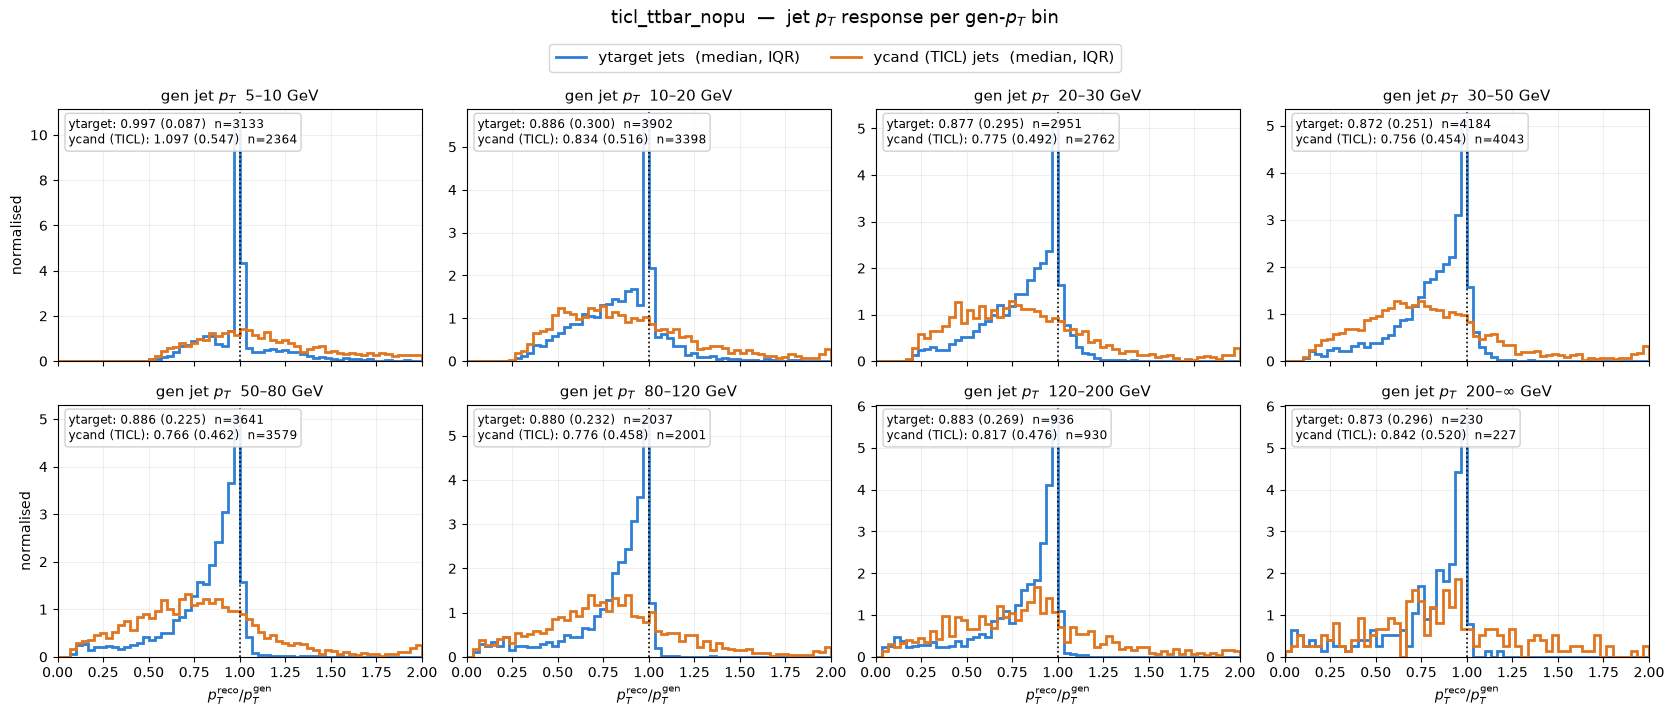

In [3]:
PT_BINS = [(5,10),(10,20),(20,30),(30,50),(50,80),(80,120),(120,200),(200,10000)]
COL = {"target": "#2f7fd4", "cand": "#e0761f"}
LAB = {"target": "ytarget", "cand": "ycand (TICL)"}
bins = np.linspace(0, 2, 61)

R = {k: np.array(v) for k, v in resp.items()}
G = {k: np.array(v) for k, v in gpt_all.items()}

ncol = 4
nrow = int(np.ceil(len(PT_BINS) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), sharex=True)
axs = np.atleast_1d(axs).ravel()
for ax, (lo, hi) in zip(axs, PT_BINS):
    txt = []
    for name in ("target", "cand"):
        m = (G[name] >= lo) & (G[name] < hi)
        if m.sum() < 10:
            continue
        r = R[name][m]
        ax.hist(r, bins=bins, histtype="step", lw=2, color=COL[name], density=True)
        txt.append(f"{LAB[name]}: {np.median(r):.3f} "
                   f"({np.percentile(r,75)-np.percentile(r,25):.3f})  n={m.sum()}")
    ax.axvline(1, color="k", ls=":", lw=1.2)
    hi_lab = "$\\infty$" if hi > 1000 else str(hi)
    ax.set_title(f"gen jet $p_T$  {lo}–{hi_lab} GeV", fontsize=11)
    ax.text(.03, .97, "\n".join(txt), transform=ax.transAxes, va="top", ha="left", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=.9))
    ax.set_xlim(0, 2); ax.grid(alpha=.2)
for ax in axs[len(PT_BINS):]:
    ax.set_visible(False)
for ax in axs[-ncol:]:
    ax.set_xlabel(r"$p_T^{\rm reco}/p_T^{\rm gen}$")
for i in range(0, len(axs), ncol):
    axs[i].set_ylabel("normalised")
h = [plt.Line2D([], [], color=COL[k], lw=2, label=f"{LAB[k]} jets  (median, IQR)") for k in ("target", "cand")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.005))
fig.suptitle(f"{SAMPLE}  —  jet $p_T$ response per gen-$p_T$ bin", y=1.045, fontsize=13)
plt.tight_layout(); plt.show()


/var/folders/z8/kkxz8ypj3jd1m6y16bw_d1vw0000gn/T/ipykernel_47479/3968596812.py:22: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  for ev in pickle.load(open(fn, "rb")):


ticl_ttbar_nopu: 9570 events, gen = matched pythia (status 1), no neutrinos, |eta|>1.5
  totals: gen 213031  target 160599  ratio 0.754   per event 22.3 -> 16.8

  pt bin             photon     charged had     neutral had        electron            muon
  0-1           0 10743  nan     0   221  nan     0  2598  nan     0     9  nan               -
  1-2       40064 32309 0.81 24432 11386 0.47 14381  6392 0.44   227    43 0.19    55    33 0.60
  2-5       25121 17847 0.71 38491 25342 0.66 13207  7731 0.59   377   170 0.45   235   213 0.91
  5-10       7609  4976 0.65 18727 15998 0.85  5552  3654 0.66   329   261 0.79   328   302 0.92
  10-20      3013  2302 0.76  9347  8325 0.89  3171  2134 0.67   357   292 0.82   390   368 0.94
  20-50       876  1054 1.20  3569  3167 0.89  1279   841 0.66   434   368 0.85   436   417 0.96
  50-100       74   175 2.36   339   326 0.96   118    88 0.75   180   151 0.84   170   168 0.99
  100+          7    40 5.71    49    56 1.14     7    23 3.29    43

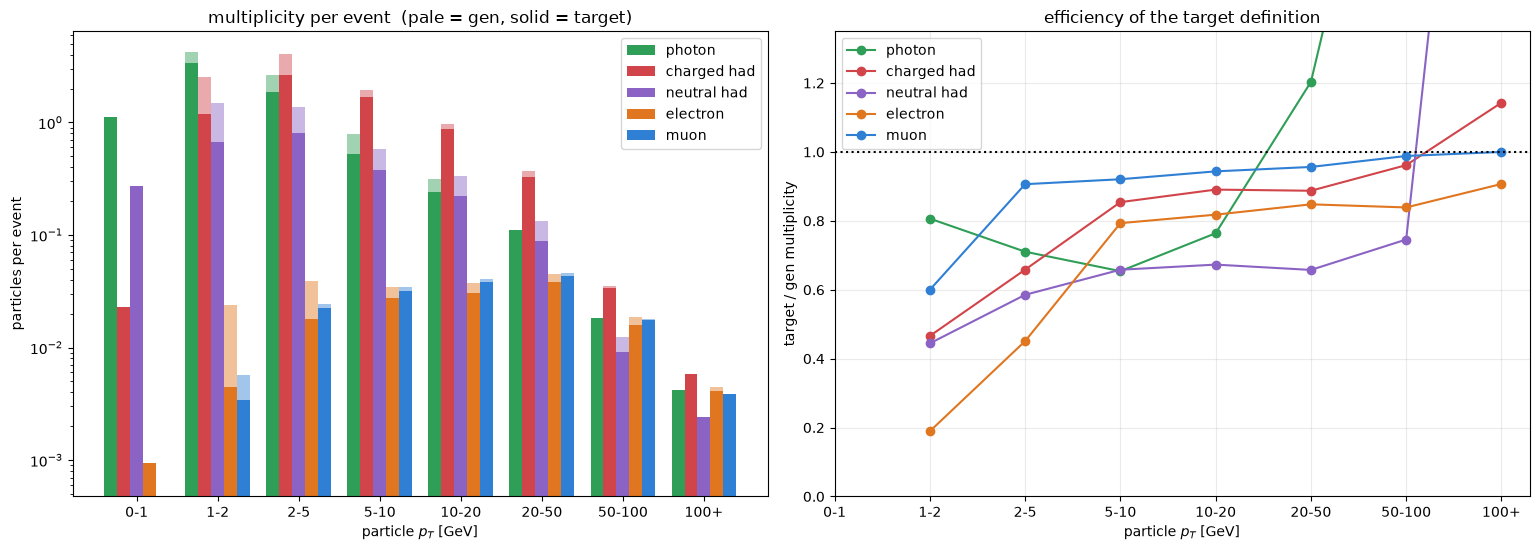

In [4]:
PKL_DIR = "../data/cms/phase2/offline/Aug31/nano/pkl_output"
SAMPLE, NFILES = "ticl_ttbar_nopu", 12
ETA_MIN = 1.5
NU = {12, 14, 16}
CHH = {211, 321, 2212, 3222, 3112, 3312, 411, 431, 521}   # -> charged hadron
NEH = {130, 310, 2112, 3122, 3322, 3334}                  # -> neutral hadron
PT_EDGES = np.array([0, 1, 2, 5, 10, 20, 50, 100, 1e9])
PT_LAB = ["0-1", "1-2", "2-5", "5-10", "10-20", "20-50", "50-100", "100+"]
CLASSES = [(22, "photon"), (211, "charged had"), (130, "neutral had"), (11, "electron"), (13, "muon")]

def fold(p):
    p = abs(int(p))
    if p in (22, 11, 13): return p
    if p in CHH: return 211
    if p in NEH: return 130
    return 0

gen = {k: np.zeros(len(PT_LAB)) for k, _ in CLASSES}
tgt = {k: np.zeros(len(PT_LAB)) for k, _ in CLASSES}
nev = 0
for fn in sorted(glob.glob(f"{PKL_DIR}/{SAMPLE}_*.pkl"))[:NFILES]:
    for ev in pickle.load(open(fn, "rb")):
        P = ev["pythia"]
        if P.ndim != 2 or len(P) == 0: continue
        nev += 1
        m = (~np.isin(np.abs(P[:, 0]).astype(int), list(NU))) & (np.abs(P[:, 2]) >= ETA_MIN)
        for pid, pt in zip(P[m, 0], P[m, 1]):
            k = fold(pid)
            if k in gen: gen[k][np.searchsorted(PT_EDGES, pt, "right") - 1] += 1
        y = ev["ytarget"]; v = y["pid"] != 0
        for pid, pt in zip(y["pid"][v], y["pt"][v]):
            k = abs(int(pid))
            if k in tgt: tgt[k][np.searchsorted(PT_EDGES, pt, "right") - 1] += 1

gt = sum(gen[k].sum() for k, _ in CLASSES); tt = sum(tgt[k].sum() for k, _ in CLASSES)
print(f"{SAMPLE}: {nev} events, gen = matched pythia (status 1), no neutrinos, |eta|>{ETA_MIN}")
print(f"  totals: gen {gt:.0f}  target {tt:.0f}  ratio {tt/gt:.3f}   per event {gt/nev:.1f} -> {tt/nev:.1f}\n")
print(f"  {'pt bin':<9}" + "".join(f"{n:>16}" for _, n in CLASSES))
for i, lab in enumerate(PT_LAB):
    row = f"  {lab:<9}"
    for k, _ in CLASSES:
        g, t = gen[k][i], tgt[k][i]
        row += f"{g:6.0f}{t:6.0f}{(t/g if g else np.nan):5.2f}" if g or t else f"{'-':>16}"
    print(row)

fig, axs = plt.subplots(1, 2, figsize=(15.5, 5.6))
x = np.arange(len(PT_LAB)); w = 0.8 / len(CLASSES)
COL = dict(zip([k for k, _ in CLASSES], ["#2f9e56", "#d1444a", "#8a63c4", "#e0761f", "#2f7fd4"]))
for j, (k, nm) in enumerate(CLASSES):
    axs[0].bar(x + (j - 2) * w, gen[k] / nev, w, color=COL[k], alpha=.45)
    axs[0].bar(x + (j - 2) * w, tgt[k] / nev, w, color=COL[k], label=nm)
axs[0].set_yscale("log"); axs[0].set_xticks(x); axs[0].set_xticklabels(PT_LAB)
axs[0].set_xlabel(r"particle $p_T$ [GeV]"); axs[0].set_ylabel("particles per event")
axs[0].set_title("multiplicity per event  (pale = gen, solid = target)"); axs[0].legend(fontsize=10)

for k, nm in CLASSES:
    r = np.where(gen[k] > 0, tgt[k] / np.maximum(gen[k], 1), np.nan)
    axs[1].plot(x, r, "o-", color=COL[k], label=nm)
axs[1].axhline(1, color="k", ls=":", lw=1.5)
axs[1].set_xticks(x); axs[1].set_xticklabels(PT_LAB); axs[1].set_ylim(0, 1.35)
axs[1].set_xlabel(r"particle $p_T$ [GeV]"); axs[1].set_ylabel("target / gen multiplicity")
axs[1].set_title("efficiency of the target definition"); axs[1].legend(fontsize=10); axs[1].grid(alpha=.25)
plt.tight_layout(); plt.show()


/var/folders/z8/kkxz8ypj3jd1m6y16bw_d1vw0000gn/T/ipykernel_47479/2376225037.py:37: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  for ev in pickle.load(open(fn, "rb")):


ticl_ttbar_nopu: gen jets pt>20.0, 13979 matched target jets

  neutral frac 0.0-0.2   ytarget: med 0.954 IQR 0.146 n= 3494   ycand (TICL): med 0.946 IQR 0.645 n= 3347
  neutral frac 0.2-0.4   ytarget: med 0.870 IQR 0.213 n= 3843   ycand (TICL): med 0.779 IQR 0.445 n= 3762
  neutral frac 0.4-0.6   ytarget: med 0.842 IQR 0.271 n= 3635   ycand (TICL): med 0.727 IQR 0.405 n= 3544
  neutral frac 0.6-0.8   ytarget: med 0.805 IQR 0.337 n= 2045   ycand (TICL): med 0.667 IQR 0.403 n= 1986
  neutral frac 0.8-1.0   ytarget: med 0.828 IQR 0.392 n=  962   ycand (TICL): med 0.619 IQR 0.445 n=  903


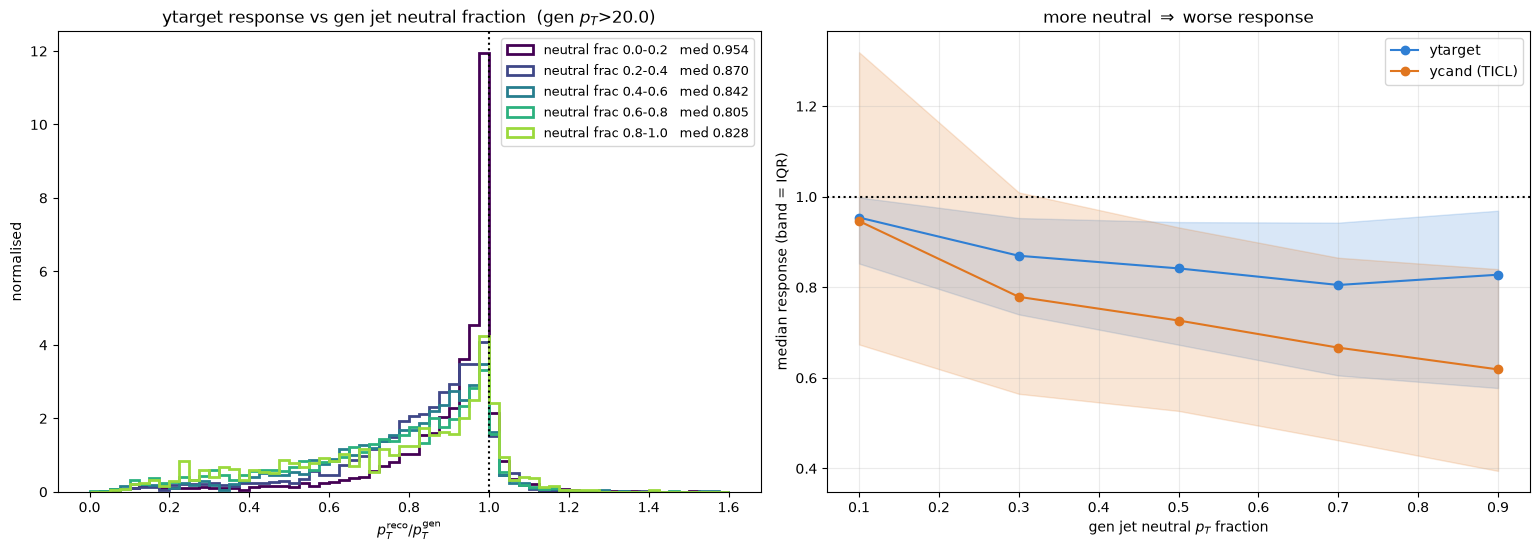

In [5]:
PKL_DIR = "../data/cms/phase2/offline/Aug31/nano/pkl_output"
SAMPLE, NFILES = "ticl_ttbar_nopu", 12
JET_PT_MIN, DR_MATCH, GEN_JET_PT = 5.0, 0.2, 20.0
NU = {12, 14, 16}
NEUTRAL = {22, 130, 310, 2112, 3122, 3322, 3334}          # gen pids counted as neutral
JET_DEF = fastjet.JetDefinition(fastjet.antikt_algorithm, 0.4)

def cluster(pt, eta, phi, e, ptmin=JET_PT_MIN, tag=False):
    if len(pt) == 0:
        return np.zeros((0, 3)), []
    px, py = pt*np.cos(phi), pt*np.sin(phi)
    pz = pt*np.sinh(np.where(np.abs(eta) < 10, eta, 0.0))
    pjs = []
    for i in range(len(pt)):
        pj = fastjet.PseudoJet(float(px[i]), float(py[i]), float(pz[i]), float(e[i]))
        pj.set_user_index(i); pjs.append(pj)
    cs = fastjet.ClusterSequence(pjs, JET_DEF)     # must stay alive while reading constituents
    jets = cs.inclusive_jets(ptmin=ptmin)
    if not jets:
        return np.zeros((0, 3)), []
    arr = np.array([[j.pt(), j.eta(), j.phi()] for j in jets])
    con = [[c.user_index() for c in j.constituents()] for j in jets] if tag else []
    del cs
    return arr, con

def match(ref, other, dr=DR_MATCH):
    out = np.full(len(ref), -1, int)
    if len(other) == 0 or len(ref) == 0: return out
    for i, (_, e1, p1) in enumerate(ref):
        d = np.hypot(other[:,1]-e1, (other[:,2]-p1+np.pi) % (2*np.pi) - np.pi)
        j = int(np.argmin(d))
        if d[j] < dr: out[i] = j
    return out

nef, resp = {"target": [], "cand": []}, {"target": [], "cand": []}
for fn in sorted(glob.glob(f"{PKL_DIR}/{SAMPLE}_*.pkl"))[:NFILES]:
    for ev in pickle.load(open(fn, "rb")):
        P = ev["pythia"]
        if P.ndim != 2 or len(P) == 0: continue
        g = P[~np.isin(np.abs(P[:,0]).astype(int), list(NU))]
        gj, gcon = cluster(g[:,1], g[:,2], g[:,3], g[:,4], ptmin=GEN_JET_PT, tag=True)
        if len(gj) == 0: continue
        isneu = np.isin(np.abs(g[:,0]).astype(int), list(NEUTRAL))
        f_neu = np.array([g[c,1][isneu[c]].sum() / max(g[c,1].sum(), 1e-9) for c in gcon])
        for name, y in [("target", ev["ytarget"]), ("cand", ev["ycand"])]:
            v = y["pid"] != 0
            rj, _ = cluster(y["pt"][v], y["eta"][v],
                            np.arctan2(y["sin_phi"][v], y["cos_phi"][v]), y["energy"][v])
            m = match(gj, rj); ok = m >= 0
            resp[name] += (rj[m[ok], 0] / gj[ok, 0]).tolist()
            nef[name] += f_neu[ok].tolist()

BINS = [(0.0,0.2),(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.01)]
COL = {"target": "#2f7fd4", "cand": "#e0761f"}; LAB = {"target": "ytarget", "cand": "ycand (TICL)"}
R = {k: np.array(v) for k,v in resp.items()}; F = {k: np.array(v) for k,v in nef.items()}
print(f"{SAMPLE}: gen jets pt>{GEN_JET_PT}, {len(R['target'])} matched target jets\n")
for lo, hi in BINS:
    row = f"  neutral frac {lo:.1f}-{min(hi,1.0):.1f}"
    for k in ("target","cand"):
        m = (F[k]>=lo)&(F[k]<hi)
        row += (f"   {LAB[k]}: med {np.median(R[k][m]):.3f} "
                f"IQR {np.percentile(R[k][m],75)-np.percentile(R[k][m],25):.3f} n={m.sum():5d}") if m.sum()>20 else ""
    print(row)

fig, axs = plt.subplots(1, 2, figsize=(15.5, 5.6))
bins = np.linspace(0, 1.6, 65)
cmap = plt.cm.viridis(np.linspace(0, .85, len(BINS)))
for (lo, hi), c in zip(BINS, cmap):
    m = (F["target"]>=lo)&(F["target"]<hi)
    if m.sum() > 20:
        axs[0].hist(R["target"][m], bins=bins, histtype="step", lw=2, color=c, density=True,
                    label=f"neutral frac {lo:.1f}-{min(hi,1.0):.1f}   med {np.median(R['target'][m]):.3f}")
axs[0].axvline(1, color="k", ls=":", lw=1.5); axs[0].legend(fontsize=9.5)
axs[0].set_xlabel(r"$p_T^{\rm reco}/p_T^{\rm gen}$"); axs[0].set_ylabel("normalised")
axs[0].set_title(f"ytarget response vs gen jet neutral fraction  (gen $p_T$>{GEN_JET_PT})")

ctr = [(lo+min(hi,1.0))/2 for lo,hi in BINS]
for k in ("target","cand"):
    med, q1, q3 = [], [], []
    for lo, hi in BINS:
        m = (F[k]>=lo)&(F[k]<hi)
        v = R[k][m] if m.sum()>20 else np.array([np.nan])
        med.append(np.median(v)); q1.append(np.percentile(v,25)); q3.append(np.percentile(v,75))
    axs[1].plot(ctr, med, "o-", color=COL[k], label=LAB[k])
    axs[1].fill_between(ctr, q1, q3, color=COL[k], alpha=.18)
axs[1].axhline(1, color="k", ls=":", lw=1.5); axs[1].grid(alpha=.25); axs[1].legend(fontsize=10)
axs[1].set_xlabel("gen jet neutral $p_T$ fraction"); axs[1].set_ylabel("median response (band = IQR)")
axs[1].set_title("more neutral $\\Rightarrow$ worse response")
plt.tight_layout(); plt.show()


/var/folders/z8/kkxz8ypj3jd1m6y16bw_d1vw0000gn/T/ipykernel_47479/945048584.py:25: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  for ev in pickle.load(open(fn, "rb")):


ticl_ttbar_nopu: 13979 matched jet pairs (gen pt>20.0)

  neutral pt fraction : gen mean 0.394   target mean 0.389   diff -0.006
  total   response    : median 0.879
  CHARGED response    : median 0.921   (sum ratio 0.847)
  NEUTRAL response    : median 0.830   (sum ratio 0.737)
    f_neu 0.0-0.2: n= 3494  gen 0.072 -> tgt 0.048   charged resp 0.967   neutral resp 0.557
    f_neu 0.2-0.4: n= 3843  gen 0.305 -> tgt 0.284   charged resp 0.916   neutral resp 0.873
    f_neu 0.4-0.6: n= 3635  gen 0.494 -> tgt 0.476   charged resp 0.898   neutral resp 0.862
    f_neu 0.6-0.8: n= 2045  gen 0.685 -> tgt 0.684   charged resp 0.877   neutral resp 0.836
    f_neu 0.8-1.0: n=  962  gen 0.888 -> tgt 0.936   charged resp 0.512   neutral resp 0.863


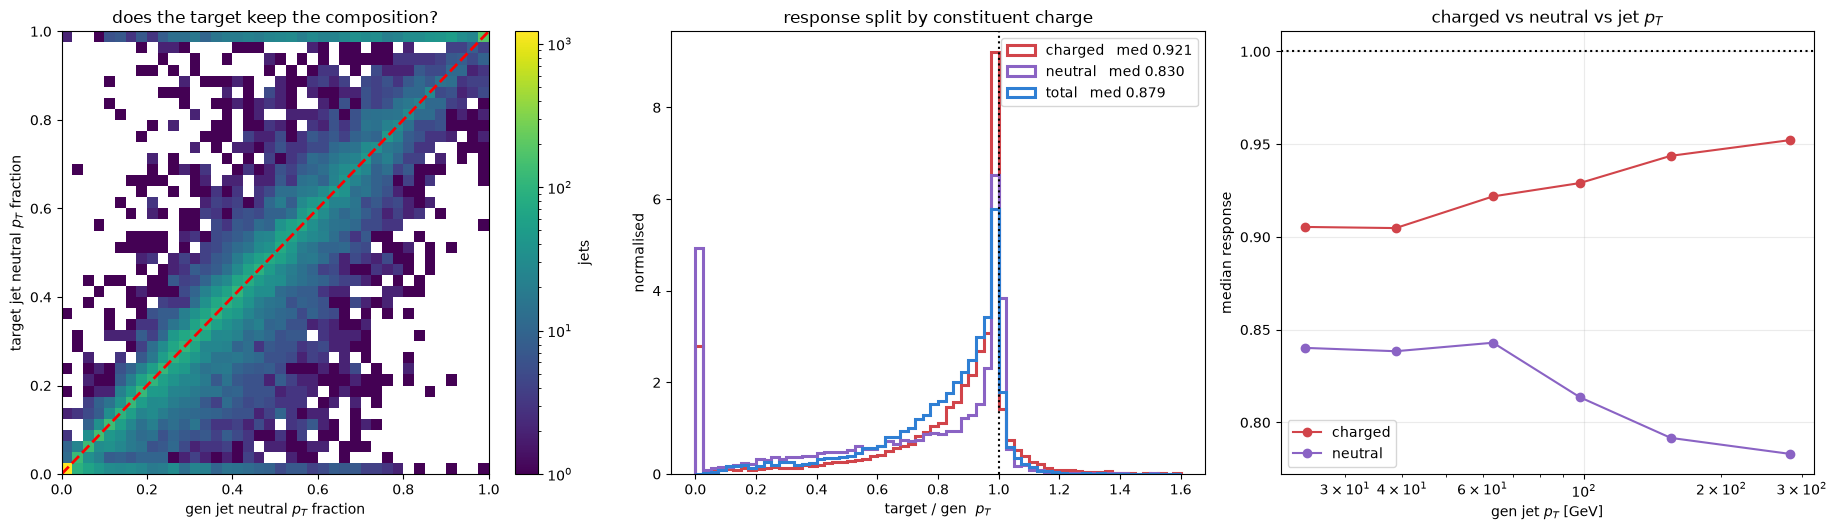

In [6]:
PKL_DIR = "../data/cms/phase2/offline/Aug31/nano/pkl_output"
SAMPLE, NFILES = "ticl_ttbar_nopu", 12
GEN_JET_PT, RECO_JET_PT, DR_MATCH = 20.0, 5.0, 0.2
NU = {12, 14, 16}
NEU_GEN = {22, 130, 310, 2112, 3122, 3322, 3334}
NEU_TGT = {22, 130}
JET_DEF = fastjet.JetDefinition(fastjet.antikt_algorithm, 0.4)

def cluster(pt, eta, phi, e, ptmin):
    if len(pt) == 0: return []
    px, py = pt*np.cos(phi), pt*np.sin(phi)
    pz = pt*np.sinh(np.where(np.abs(eta) < 10, eta, 0.0))
    pjs = []
    for i in range(len(pt)):
        j = fastjet.PseudoJet(float(px[i]), float(py[i]), float(pz[i]), float(e[i]))
        j.set_user_index(i); pjs.append(j)
    cs = fastjet.ClusterSequence(pjs, JET_DEF)
    out = [(j.pt(), j.eta(), j.phi(), [c.user_index() for c in j.constituents()])
           for j in cs.inclusive_jets(ptmin=ptmin)]
    del cs
    return out

rows = []
for fn in sorted(glob.glob(f"{PKL_DIR}/{SAMPLE}_*.pkl"))[:NFILES]:
    for ev in pickle.load(open(fn, "rb")):
        P = ev["pythia"]
        if P.ndim != 2 or len(P) == 0: continue
        g = P[~np.isin(np.abs(P[:,0]).astype(int), list(NU))]
        gjets = cluster(g[:,1], g[:,2], g[:,3], g[:,4], GEN_JET_PT)
        if not gjets: continue
        gneu = np.isin(np.abs(g[:,0]).astype(int), list(NEU_GEN))
        y = ev["ytarget"]; v = y["pid"] != 0
        tpt, teta = y["pt"][v], y["eta"][v]
        tphi = np.arctan2(y["sin_phi"][v], y["cos_phi"][v]); ten = y["energy"][v]
        tneu = np.isin(np.abs(y["pid"][v]).astype(int), list(NEU_TGT))
        tjets = cluster(tpt, teta, tphi, ten, RECO_JET_PT)
        if not tjets: continue
        tarr = np.array([[j[0], j[1], j[2]] for j in tjets])
        for gpt_, geta, gphi, gc in gjets:
            d = np.hypot(tarr[:,1]-geta, (tarr[:,2]-gphi+np.pi) % (2*np.pi) - np.pi)
            k = int(np.argmin(d))
            if d[k] >= DR_MATCH: continue
            gc, tc = np.array(gc), np.array(tjets[k][3])
            rows.append((gpt_, tjets[k][0],
                         g[gc,1][gneu[gc]].sum(), g[gc,1][~gneu[gc]].sum(),
                         tpt[tc][tneu[tc]].sum(), tpt[tc][~tneu[tc]].sum()))
R = np.array(rows)
gpt, tpt_, gn, gch, tn, tch = R.T
fg, ft = gn/(gn+gch), tn/(tn+tch)
rch, rn = tch/np.maximum(gch, 1e-9), tn/np.maximum(gn, 1e-9)

print(f"{SAMPLE}: {len(R)} matched jet pairs (gen pt>{GEN_JET_PT})\n")
print(f"  neutral pt fraction : gen mean {fg.mean():.3f}   target mean {ft.mean():.3f}   diff {ft.mean()-fg.mean():+.3f}")
print(f"  total   response    : median {np.median(tpt_/gpt):.3f}")
print(f"  CHARGED response    : median {np.median(rch):.3f}   (sum ratio {tch.sum()/gch.sum():.3f})")
print(f"  NEUTRAL response    : median {np.median(rn):.3f}   (sum ratio {tn.sum()/gn.sum():.3f})")
for lo, hi in [(0,.2),(.2,.4),(.4,.6),(.6,.8),(.8,1.01)]:
    m = (fg >= lo) & (fg < hi)
    if m.sum() > 20:
        print(f"    f_neu {lo:.1f}-{min(hi,1):.1f}: n={m.sum():5d}  gen {np.median(fg[m]):.3f} -> tgt {np.median(ft[m]):.3f}"
              f"   charged resp {np.median(rch[m]):.3f}   neutral resp {np.median(rn[m]):.3f}")

fig, axs = plt.subplots(1, 3, figsize=(18.5, 5.4))
h = axs[0].hist2d(fg, ft, bins=[np.linspace(0,1,41)]*2, norm="log", cmap="viridis")
axs[0].plot([0,1],[0,1],"r--",lw=2); fig.colorbar(h[3], ax=axs[0], label="jets")
axs[0].set_xlabel("gen jet neutral $p_T$ fraction"); axs[0].set_ylabel("target jet neutral $p_T$ fraction")
axs[0].set_title("does the target keep the composition?")

b = np.linspace(0, 1.6, 65)
for lab, r, c in [("charged", rch, "#d1444a"), ("neutral", rn, "#8a63c4"), ("total", tpt_/gpt, "#2f7fd4")]:
    axs[1].hist(r, bins=b, histtype="step", lw=2.2, color=c, density=True, label=f"{lab}   med {np.median(r):.3f}")
axs[1].axvline(1, color="k", ls=":", lw=1.5); axs[1].legend(fontsize=10)
axs[1].set_xlabel(r"target / gen  $p_T$"); axs[1].set_ylabel("normalised")
axs[1].set_title("response split by constituent charge")

eb = np.array([20,30,50,80,120,200,400]); ctr = np.sqrt(eb[:-1]*eb[1:])
for lab, r, c in [("charged", rch, "#d1444a"), ("neutral", rn, "#8a63c4")]:
    med = [np.median(r[(gpt>=lo)&(gpt<hi)]) if ((gpt>=lo)&(gpt<hi)).sum()>20 else np.nan
           for lo,hi in zip(eb[:-1],eb[1:])]
    axs[2].plot(ctr, med, "o-", color=c, label=lab)
axs[2].axhline(1, color="k", ls=":", lw=1.5); axs[2].set_xscale("log"); axs[2].grid(alpha=.25)
axs[2].set_xlabel(r"gen jet $p_T$ [GeV]"); axs[2].set_ylabel("median response"); axs[2].legend(fontsize=10)
axs[2].set_title("charged vs neutral vs jet $p_T$")
plt.tight_layout(); plt.show()
